In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..', 'scripts')))

In [2]:
import carregar_dados

In [3]:
dados_consolidados = carregar_dados.carregar_e_consolidar_dados()

### 1. Análise de Desempenho Geográfico

In [19]:
# Cria uma matriz de faturamento: Região vs. Loja
heatmap_data = dados_consolidados.pivot_table(
    index='Local da compra',  
    columns='Loja',           
    values='Preço',           
    aggfunc='sum',           
    fill_value=0              
)

# Filtra para os 10 estados com maior faturamento total
top_10_estados = heatmap_data.sum(axis=1).nlargest(10).index
heatmap_data_top10 = heatmap_data.loc[top_10_estados]

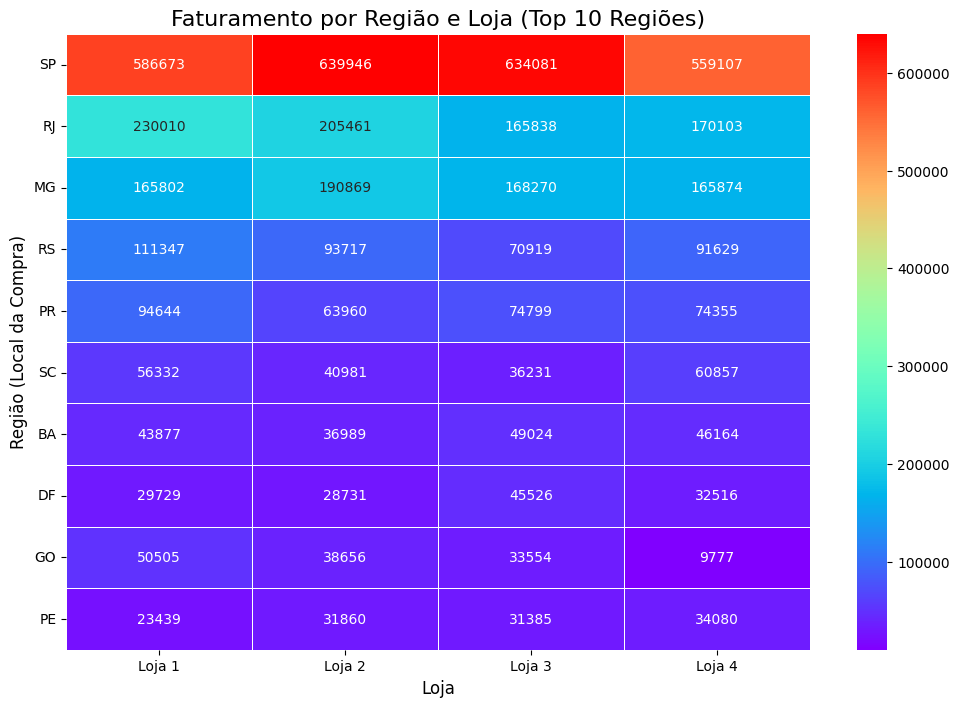

In [23]:
# Cria o gráfico
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data_top10,
    annot=True,      
    fmt=".0f",       
    cmap="rainbow", 
    linewidths=.5    
)

plt.title('Faturamento por Região e Loja (Top 10 Regiões)', fontsize=16)
plt.xlabel('Loja', fontsize=12)
plt.ylabel('Região (Local da Compra)', fontsize=12)
plt.xticks(rotation=0) #
plt.yticks(rotation=0) 

if not os.path.exists('../relatorios'):
    os.makedirs('../relatorios')
        
caminho_salvar = '../relatorios/heatmap_faturamento_regiao.png'
plt.savefig(caminho_salvar)
plt.show()

#### 2. Análise sobre Faturamento por Região

Ao analisar o mapa de dispersão gerado, podemos extrair as seguintes conclusões:

* A análise geográfica, visualizada através do heatmap, deixa claro que a região Sudeste é o principal mercado para a Alura Store. Os estados de São Paulo (SP), Rio de Janeiro (RJ) e Minas Gerais (MG) são, de longe, os que mais geram faturamento para todas as quatro lojas. A linha de São Paulo no heatmap é a mais "quente" (com as cores mais claras), indicando a maior concentração de receita.

* Não existe um domínio regional exclusivo para nenhuma das lojas. Todas as quatro unidades competem intensamente pelos mesmos clientes nos mercados mais lucrativos. Em São Paulo, por exemplo, todas as lojas possuem um faturamento robusto, mostrando que não há uma loja "dona" da região. Isso sugere que a operação logística pode ser centralizada, atendendo aos mesmos locais a partir de um ponto comum.

* A Loja 4 tem um desempenho consistentemente inferior. Ela apresenta os valores de faturamento mais baixos na maioria das regiões mais importantes, incluindo São Paulo. Isso confirma que seu baixo desempenho não é um problema localizado, mas uma dificuldade geral de competir em todos os principais mercados.

* As lojas 2 e 3 apresentam uma performance sólida e competitiva, especialmente no Rio de Janeiro, onde chegam a superar a Loja 1. Isso mostra que, embora a Loja 1 seja a líder geral, a disputa pela preferência do cliente varia de estado para estado.

* Regiões como Rio Grande do Sul (RS), Paraná (PR) e Bahia (BA) aparecem como mercados secundários importantes. Embora com um faturamento menor que o Sudeste, eles representam uma fatia relevante das vendas e podem ser áreas com potencial de crescimento se forem alvo de estratégias de marketing mais focadas.

#### 3. Conclusão

A análise regional é fundamental para a recomendação final. Ela confirma que a Loja 4 não apenas fatura menos no geral, mas também é a menos competitiva nos mercados que mais importam. Sua dificuldade em se destacar em São Paulo e Minas Gerais é um forte indicativo de sua menor eficiência, tornando-a a candidata mais clara para a venda.